# Phase 3 — the PU decoder-curvature field, and what calibrates it

**This is a PRESENTATION notebook. It trains nothing.** It loads the runners' recorded JSONL
output from the gitignored cache and renders it. No fit, no sweep, no expensive computation
runs inline here.

It must not be confused with the CLAUDE.md-mandated Swiss roll sanity check, which is a
different document with a different job: `notebooks/03_swiss_roll_chart_curvature_field_check.ipynb`
(plan 03-06) generates its data in-notebook and trains from scratch in under two minutes. This
notebook may read the cache freely; that one may not touch it.

Sources rendered here:

| record | produced by |
|---|---|
| `notebooks/.cache/03_curvature_field_pu.jsonl` | `curvature_field_pu_run.py` — the nine-cell grid, the converged fit, the field, the bridge |
| `notebooks/.cache/03_synthetic_controls.jsonl` | `synthetic_control_run.py` — the flat/sphere/saddle controls at d=20 and the d=4 discriminator |

**Read the caveats at the end before quoting any number from this notebook.**

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

CACHE = Path("notebooks/.cache") if Path("notebooks/.cache").exists() else Path(".cache")
PU_RECORDS = CACHE / "03_curvature_field_pu.jsonl"
CONTROL_RECORDS = CACHE / "03_synthetic_controls.jsonl"


def load_completed(path):
    """Every JSON-lines record on disk, keyed by config_id -- the same reader shape the
    runners use. Missing file -> empty dict rather than an exception."""
    out = {}
    if not path.exists():
        return out
    with path.open() as f:
        for line in f:
            line = line.strip()
            if line:
                rec = json.loads(line)
                out[rec["config_id"]] = rec
    return out


pu = load_completed(PU_RECORDS)
ctl = load_completed(CONTROL_RECORDS)

def of_kind(recs, kind):
    return {k: v for k, v in recs.items() if v.get("kind") == kind}

print(f"PU records      : {len(pu):3d} from {PU_RECORDS}")
for kind in sorted({v.get("kind") for v in pu.values()}):
    print(f"    {kind:22s} {len(of_kind(pu, kind))}")
print(f"Control records : {len(ctl):3d} from {CONTROL_RECORDS}")
for kind in sorted({v.get("kind") for v in ctl.values()}):
    print(f"    {kind:22s} {len(of_kind(ctl, kind))}")

PU records      :  18 from .cache/03_curvature_field_pu.jsonl
    bridge_cell            1
    control_cell           6
    converge_cell          1
    field_cell             1
    grid_cell              9
Control records :   5 from .cache/03_synthetic_controls.jsonl
    control_fit            5


## 1. Step 1 — the D-07 selection table

Four diagnostics, kept uncollapsed, three seeds each. The rule below was declared in plan
03-07 **before any PU number existed** and applied unchanged; `git diff` over the runner shows
no edit to the ranking function since. Its first axis decided the outcome outright, so no
lower axis was reached and no axis was tied.

**Lexicographic rule:** disqualify median occupancy `< 2`; then rank by median `max cond(g)`
with a factor-of-2 tie band; then median `mse_per_dim`; then median
`latent|ambient|H1|bottleneck_norm`. **No composite score is formed anywhere.**

In [2]:
grid = of_kind(pu, "grid_cell")
rows = []
for rec in grid.values():
    rows.append((
        int(rec["n_charts"]), int(rec["seed"]), int(rec["epochs_run"]), bool(rec["early_stopped"]),
        rec["occupancy"]["n_distinct_charts"], rec["cond"]["median"], rec["cond"]["max"],
        rec["reconstruction"]["mse_per_dim"],
        rec["ph"]["latent|ambient|H0|bottleneck_norm"], rec["ph"]["latent|ambient|H1|bottleneck_norm"],
    ))
rows.sort()
hdr = f"{'nc':>3} {'seed':>9} {'ep':>3} {'stop':>5} {'occ':>4} {'cond med':>11} {'cond max':>11} {'mse/dim':>11} {'H0':>7} {'H1':>7}"
print("PER-SEED, nothing collapsed:"); print(hdr); print("-" * len(hdr))
for r in rows:
    print(f"{r[0]:>3} {r[1]:>9} {r[2]:>3} {str(r[3]):>5} {r[4]:>4} {r[5]:>11.4g} {r[6]:>11.4g} {r[7]:>11.4g} {r[8]:>7.4g} {r[9]:>7.4g}")

print("\nACROSS-SEED MEDIANS (the unit the rule reads):")
for nc in sorted({r[0] for r in rows}):
    sub = [r for r in rows if r[0] == nc]
    print(f"  n_charts={nc:>3}  occ={np.median([s[4] for s in sub]):.2f}"
          f"  max_cond={np.median([s[6] for s in sub]):.4g}"
          f"  mse/dim={np.median([s[7] for s in sub]):.6g}"
          f"  H1={np.median([s[9] for s in sub]):.4g}")
print("\nSelected n_charts: 4 -- decided on axis 1 (conditioning) outright; no axis tied.")
print("The Swiss roll's winning n_charts was 2. It played no part and is not in the swept set.")

PER-SEED, nothing collapsed:
 nc      seed  ep  stop  occ    cond med    cond max     mse/dim      H0      H1
--------------------------------------------------------------------------------
  4  20260813  30  True    2   9.758e+06   4.886e+07   0.0001247  0.6217  0.8451
  4  20260814  27  True    1       365.7       365.7   0.0002438   2.362     0.5
  4  20260815  27  True    3        1357   2.233e+04   0.0001733     0.5   1.031
  8  20260813  40 False    7       840.7   8.526e+04   0.0001429  0.4486  0.6294
  8  20260814  32  True    2   4.805e+06   2.137e+07   0.0001227   0.323  0.8122
  8  20260815  40 False    6   4.051e+06   3.133e+07   8.899e-05  0.3052  0.9964
 16  20260813  40 False   15   1.409e+04   1.495e+05   0.0001268  0.4484  0.7071
 16  20260814  40 False    6   7.682e+06   4.202e+07   0.0001203  0.4014  0.5568
 16  20260815  40 False   10   7.928e+06   3.239e+07   0.0001053  0.9331  0.6451

ACROSS-SEED MEDIANS (the unit the rule reads):
  n_charts=  4  occ=2.00  max_co

### What the rule's answer rests on

Stated here rather than left for a reader to derive, because the whole downstream field is
computed on this configuration:

- `n_charts = 4` is the **worst** of the three on reconstruction *and* on occupancy. It won on
  conditioning alone.
- It clears the occupancy disqualifier (`median < 2`) by **exactly zero margin**: its median is
  `2.00`.
- Its winning axis has a **five-order-of-magnitude across-seed spread** (`max cond(g)` of
  4.886e+07, 3.657e+02, 2.233e+04), and the seed that pulls the median down collapsed onto a
  **single chart** — a degenerate parameterization is well-conditioned *because* it is degenerate.

## 2. The converged fit — removing total-loss early stopping

the CAE training loop early-stops on **total** loss (reconstruction + cross-entropy + Lipschitz), so the
grid fits halted while reconstruction was still descending. Making the patience structurally
inert took the selected config from 30 epochs to a full 300.

converge_nc4_seed20260813_ep300: epochs_run=300/300 early_stopped=False
  train recon: first=0.293751 final=0.0289358 best@epoch 300
  trailing 25-epoch relative improvement=0.05271 (tol 1.0e-03) -> STILL_DESCENDING
  holdout mse_per_dim=4.71087e-05  vs the 40-epoch grid cell 0.000124744  (-62.2%)
  cond(g): median=1.003e+07 max=3.675e+07   (the 40-epoch cell: median 9.758e+06, max 4.886e+07)
  argmax occupancy: 2 of 4


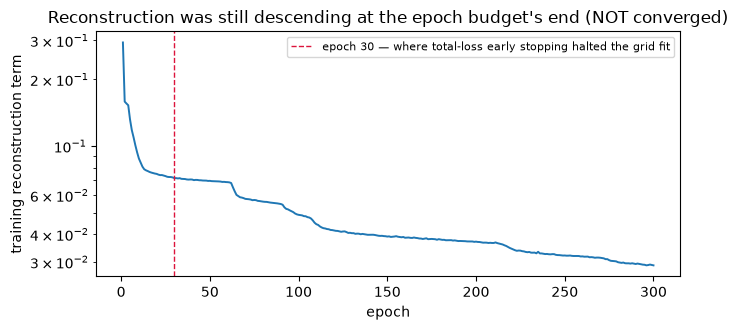

In [3]:
conv = of_kind(pu, "converge_cell")
for rec in conv.values():
    pl = rec["plateau"]
    print(f"{rec['config_id']}: epochs_run={rec['epochs_run']}/{rec['max_epochs']}"
          f" early_stopped={rec['early_stopped']}")
    print(f"  train recon: first={pl['recon_first']:.6g} final={pl['recon_final']:.6g}"
          f" best@epoch {pl['recon_best_epoch']}")
    print(f"  trailing {pl['window']}-epoch relative improvement={pl['rel_improvement_over_window']:.4g}"
          f" (tol {pl['rel_tol']:.1e}) -> {pl['status'].upper()}")
    print(f"  holdout mse_per_dim={rec['reconstruction']['mse_per_dim']:.6g}"
          f"  vs the 40-epoch grid cell {rec['grid_baseline_mse_per_dim']:.6g}"
          f"  ({100*(rec['reconstruction']['mse_per_dim']/rec['grid_baseline_mse_per_dim']-1):+.1f}%)")
    print(f"  cond(g): median={rec['cond']['median']:.4g} max={rec['cond']['max']:.4g}"
          f"   (the 40-epoch cell: median 9.758e+06, max 4.886e+07)")
    print(f"  argmax occupancy: {rec['occupancy']['n_distinct_charts']} of {rec['n_charts']}")

    curve = rec["recon_curve_main"]
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.plot(np.arange(1, len(curve) + 1), curve, lw=1.4)
    ax.axvline(30, ls="--", c="crimson", lw=1,
               label="epoch 30 — where total-loss early stopping halted the grid fit")
    ax.set_xlabel("epoch"); ax.set_ylabel("training reconstruction term")
    ax.set_yscale("log"); ax.legend(fontsize=8)
    ax.set_title("Reconstruction was still descending at the epoch budget's end (NOT converged)")
    plt.tight_layout(); plt.show()

**Reconstruction fell 62.2% and `cond(g)` did not move.** The training objective
regularizes `chart_encoders` via `lipschitz_penalty`; curvature is decoded through
`chart_decoders` composed with `embedding_decoder`. Those sets **share no parameter**, so
nothing in the objective constrains the decoder's derivatives at any order — and training
longer on a C0 objective bought nothing at C2.

The curve's best epoch is its **last**: the budget ended training, not convergence.

## 3. Steps 2 and 3 — the ‖H‖ field, its conditioning, and the bridge

`‖H‖` is the mean-curvature **VECTOR NORM**. Never Gaussian curvature, never a principal
curvature: at codimension 768 − 20 there is no canonical normal direction, so any signed
scalar reduction would flip sign with an arbitrary choice.

In [4]:
field = of_kind(pu, "field_cell")
print("PU curvature field -- one seed of three (a PROBE; the reported unit is a three-seed spread)\n")
for rec in field.values():
    h, c, f = rec["h_norm"], rec["cond"], rec["flagged"]
    print(f"seed={rec['seed']}  n_points={rec['n_points']}  charts_used={rec['n_charts_used']}"
          f"  wall clock={rec['field_wallclock_s']:.1f}s")
    print(f"  ||H|| (mean curvature VECTOR NORM, unflagged n={h['n']}):")
    print(f"    min={h['min']:.4e} p25={h['p25']:.4e} median={h['median']:.4e}"
          f" p75={h['p75']:.4e} p95={h['p95']:.4e} max={h['max']:.4e}")
    print(f"  cond(g): median={c['median']:.4e} p90={c['p90']:.4e} p99={c['p99']:.4e} max={c['max']:.4e}")
    print(f"  flagged at the within-config {f['percentile']:.0f}th cond(g) percentile: "
          f"{f['count']} points ({100*f['fraction']:.2f}%) -- reported separately, NOT averaged in")
    print(f"    flagged ||H|| mean={np.mean(f['h_norm_of_flagged']):.4e} vs unflagged mean={h['mean']:.4e}")
    ne, sd = rec["no_extrapolation"], rec["second_derivative"]
    print(f"  no-extrapolation: assignment recomputed independently -> "
          f"{'MATCHES' if ne['assignment_matches_field'] else 'DISAGREES'}; "
          f"{ne['constructed_points']} constructed points")
    print(f"  second derivatives on {sd['n_rows']} HELD-OUT rows: max|Hessian|={sd['hessian_max_abs_entry']:.4e}"
          f" positive={sd['hessian_strictly_positive']} finite={sd['hessian_all_finite']}")

PU curvature field -- one seed of three (a PROBE; the reported unit is a three-seed spread)

seed=20260813  n_points=10000  charts_used=2  wall clock=3129.5s
  ||H|| (mean curvature VECTOR NORM, unflagged n=9900):
    min=6.8133e+02 p25=1.1579e+03 median=1.3590e+03 p75=1.6539e+03 p95=2.3913e+03 max=4.2839e+03
  cond(g): median=9.9321e+06 p90=1.5828e+07 p99=2.3116e+07 max=3.8212e+07
  flagged at the within-config 99th cond(g) percentile: 100 points (1.00%) -- reported separately, NOT averaged in
    flagged ||H|| mean=2.0574e+03 vs unflagged mean=1.4683e+03
  no-extrapolation: assignment recomputed independently -> MATCHES; 0 constructed points
  second derivatives on 64 HELD-OUT rows: max|Hessian|=6.6968e-01 positive=True finite=True


<>:21: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:21: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
/tmp/ipykernel_4053554/3711382271.py:21: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
  axes[2].set_title("Joint: small $\|H\|$ from cancellation vs\nfrom a near-singular metric")


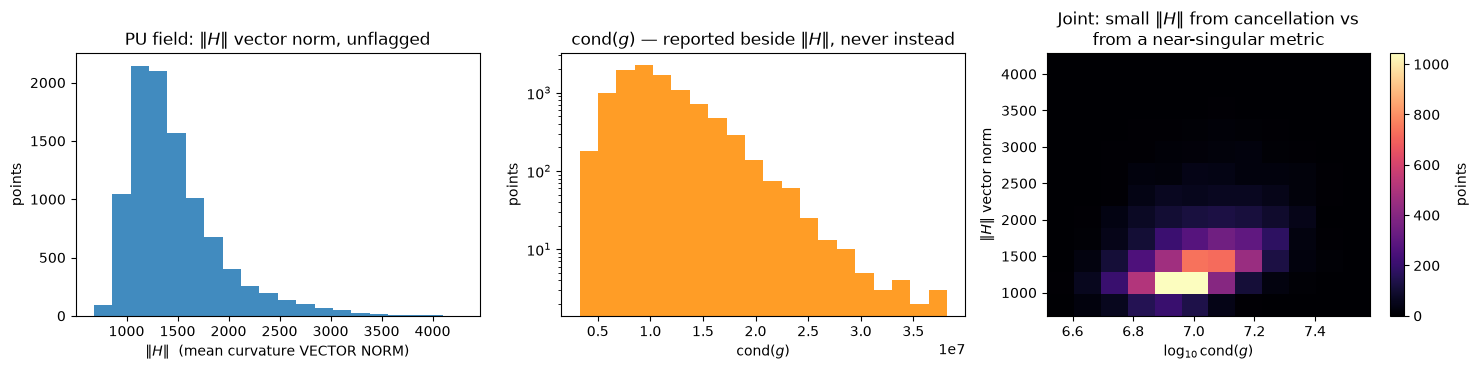

The joint panel is the point: mass shifts toward higher cond(g) as ||H|| rises, so the
large-||H|| tail is at least partly conditioning-driven -- invisible in either marginal.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for rec in field.values():
    h, c = rec["h_norm"], rec["cond"]
    edges = np.array(h["hist_edges"]); counts = np.array(h["hist_counts"])
    axes[0].bar(edges[:-1], counts, width=np.diff(edges), align="edge", alpha=0.85)
    axes[0].set_xlabel(r"$\|H\|$  (mean curvature VECTOR NORM)")
    axes[0].set_ylabel("points")
    axes[0].set_title(r"PU field: $\|H\|$ vector norm, unflagged")

    ce = np.array(c["hist_edges"]); cc = np.array(c["hist_counts"])
    axes[1].bar(ce[:-1], cc, width=np.diff(ce), align="edge", alpha=0.85, color="darkorange")
    axes[1].set_xlabel(r"$\mathrm{cond}(g)$"); axes[1].set_ylabel("points")
    axes[1].set_yscale("log")
    axes[1].set_title(r"$\mathrm{cond}(g)$ — reported beside $\|H\|$, never instead")

    j = rec["joint_hist"]
    counts2 = np.array(j["counts"]); he = np.array(j["h_norm_edges"]); le = np.array(j["log10_cond_edges"])
    im = axes[2].pcolormesh(le, he, counts2, shading="auto", cmap="magma")
    axes[2].set_xlabel(r"$\log_{10}\mathrm{cond}(g)$")
    axes[2].set_ylabel(r"$\|H\|$ vector norm")
    axes[2].set_title("Joint: small $\|H\|$ from cancellation vs\nfrom a near-singular metric")
    fig.colorbar(im, ax=axes[2], label="points")
plt.tight_layout(); plt.show()
print("The joint panel is the point: mass shifts toward higher cond(g) as ||H|| rises, so the")
print("large-||H|| tail is at least partly conditioning-driven -- invisible in either marginal.")

In [6]:
bridge = of_kind(pu, "bridge_cell")
print("Step 3 -- the independent finite-difference bridge.")
print("Agreement shows the derivative COMPUTATION is stable. It does NOT show the learned")
print("surface is correct: a net that learned a smooth but wrong surface passes cleanly.")
print("No threshold is applied and no verdict is drawn.\n")
for rec in bridge.values():
    print(f"{rec['config_id']}: {rec['evals_per_point']} evals/point vs MAX_FD_ROWS="
          f"{rec['max_fd_rows']}; BRIDGE_N_POINTS_PU>{rec['vmap_chunk']}=VMAP_CHUNK "
          f"so the WR-03 chunking fix is exercised")
    for g in rec["groups"]:
        print(f"\n  chart {g['chart_idx']}  n={g['n_points']}  fd_step={g['fd_step_used']:.4e}")
        fh = g["full_hessian_agreement"]
        print("    FULL HESSIAN AGREEMENT")
        print(f"      abs : max={fh['max_abs']:.4e} median={fh['median_abs']:.4e} p90={fh['p90_abs']:.4e}")
        print(f"      rel : max={fh['max_abs_relative']:.4e} median={fh['median_abs_relative']:.4e}"
              f" p90={fh['p90_abs_relative']:.4e}"
              f"  [near_zero_reference_fraction={fh['near_zero_reference_fraction']:.4e}]")
        print("    REDUCED MEAN-CURVATURE AGREEMENT (separate key, never combined)")
        for lvl in ("H_vec", "H_norm"):
            rm = g["reduced_mean_curvature_agreement"][lvl]
            print(f"      {lvl:6s} abs : max={rm['max_abs']:.4e} median={rm['median_abs']:.4e}")
            print(f"      {lvl:6s} rel : max={rm['max_abs_relative']:.4e} median={rm['median_abs_relative']:.4e}"
                  f"  [near_zero_reference_fraction={rm['near_zero_reference_fraction']:.4e}]")
print("\nnear_zero_reference_fraction is 0.0 everywhere, so every relative column above is a")
print("genuine ratio and not a thin denominator -- the reading 02.6-FINDINGS-02.md lacked.")
print("H_vec max relative disagreement reaches 6.21 and 23.7 while H_norm stays near 2e-04 at the")
print("same points: the curvature VECTOR's direction is unstable where its NORM is not, which is")
print("why the norm is the only reported scalar.")

Step 3 -- the independent finite-difference bridge.
Agreement shows the derivative COMPUTATION is stable. It does NOT show the learned
surface is correct: a net that learned a smooth but wrong surface passes cleanly.
No threshold is applied and no verdict is drawn.

bridge_nc4_seed20260813: 801 evals/point vs MAX_FD_ROWS=8192; BRIDGE_N_POINTS_PU>32=VMAP_CHUNK so the WR-03 chunking fix is exercised

  chart 1  n=65  fd_step=1.0000e-04
    FULL HESSIAN AGREEMENT
      abs : max=4.3994e-08 median=7.7180e-10 p90=2.6227e-09
      rel : max=1.8674e-01 median=4.6764e-08 p90=2.4586e-07  [near_zero_reference_fraction=0.0000e+00]
    REDUCED MEAN-CURVATURE AGREEMENT (separate key, never combined)
      H_vec  abs : max=2.5751e-01 median=1.4819e-02
      H_vec  rel : max=6.2101e+00 median=4.6860e-04  [near_zero_reference_fraction=0.0000e+00]
      H_norm abs : max=3.0324e-01 median=5.1407e-02
      H_norm rel : max=1.4799e-04 median=3.5161e-05  [near_zero_reference_fraction=0.0000e+00]

  chart 3

## 4. Step 4 — the synthetic controls, and the calibration they provide

Fixtures with analytic mean curvature, fitted under the same protocol. `d=20` is the matched
control; **`d=4` is a DIAGNOSTIC and not a control** — it exists to separate a broken
instrument from an under-sampled regime, and must never be quoted as a control for the PU
field.

In [7]:
fits = of_kind(ctl, "control_fit")
hdr = (f"{'fixture':>8} {'d':>3} {'ep':>4} {'recon':>11} {'cond med':>11} "
       f"{'cosine':>10} {'mag ratio':>11} {'R2':>9} {'rho':>9} {'chart':>6}")
print("FOUR AXES, FOUR COLUMNS -- no arithmetic anywhere combines them.\n")
print(hdr); print("-" * len(hdr))
for rec in sorted(fits.values(), key=lambda r: (-r["chart_dim"], r["fixture"])):
    fd = rec["fidelity"]
    if not fd.get("applicable", True):
        cos = mag = r2 = rho = "n/a(zero)"
    else:
        cos = f"{fd['direction_median_cosine']:.6f}"
        mag = f"{fd['magnitude_median_ratio']:.4g}"
        r2 = "undef" if fd.get("calibration_r2") is None else f"{fd['calibration_r2']:.6f}"
        rho = "undef" if fd.get("rank_spearman_rho") is None else f"{fd['rank_spearman_rho']:.6f}"
    print(f"{rec['fixture']:>8} {rec['chart_dim']:>3} {rec['epochs_run']:>4} "
          f"{rec['reconstruction']['mse_per_dim']:>11.4g} {rec['cond']['median']:>11.4g} "
          f"{cos:>10} {mag:>11} {r2:>9} {rho:>9} "
          f"{str(rec['n_charts_used'])+'/'+str(rec['n_charts']):>6}")

print("\n'n/a(zero)' -- flat's analytic ||H|| is exactly zero, so cosine, ratio and calibration")
print("are UNDEFINED against it; flat measures the pipeline's NOISE FLOOR instead.")
print("'undef'     -- the sphere's analytic ||H|| is CONSTANT, so rho has no ranks to correlate")
print("               and the calibration regression has a zero-variance predictor.")
print("\nNOISE FLOORS (analytic ||H|| = 0; every value measured is artifact):")
for rec in sorted(fits.values(), key=lambda r: -r["chart_dim"]):
    if "noise_floor" in rec:
        nf = rec["noise_floor"]
        print(f"  flat d={rec['chart_dim']:>2}: median={nf['measured_median']:.4e}"
              f" p95={nf['measured_p95']:.4e} max={nf['measured_max']:.4e}"
              f"   at cond(g) median {rec['cond']['median']:.4g}")
print("\nSPHERE measured-vs-analytic:")
for rec in sorted(fits.values(), key=lambda r: -r["chart_dim"]):
    if "sphere_ratio" in rec:
        sr = rec["sphere_ratio"]
        print(f"  d={rec['chart_dim']:>2}: analytic={sr['analytic_median_h_norm']:.6g}"
              f" measured={sr['measured_median_h_norm']:.6g}"
              f" ratio={sr['ratio_measured_over_analytic']:.6g}")
print("\nSADDLE trace-cancellation set (lowest 10% TRUE ||H||):")
for rec in sorted(fits.values(), key=lambda r: -r["chart_dim"]):
    if "cancellation_vs_singular" in rec:
        cs = rec["cancellation_vs_singular"]
        print(f"  d={rec['chart_dim']:>2}: est median there={cs['h_est_median_at_cancellation']:.4e}"
              f" vs overall {cs['h_est_median_overall']:.4e}"
              f"  -> {'DISTINGUISHED' if cs['h_est_median_at_cancellation'] < 0.5*cs['h_est_median_overall'] else 'NOT distinguished'}")

FOUR AXES, FOUR COLUMNS -- no arithmetic anywhere combines them.

 fixture   d   ep       recon    cond med     cosine   mag ratio        R2       rho  chart
-------------------------------------------------------------------------------------------
  saddle  20  300     0.01625    1.88e+08  -0.000478        9955  0.000002 -0.015107    4/4
  sphere  20  300     0.02133   1.532e+08   0.008875       58.46  0.000000  0.005132    3/4
    flat   4  300   1.132e-06       1.445  n/a(zero)   n/a(zero) n/a(zero) n/a(zero)    1/4
  saddle   4  300   5.112e-07       4.098   0.992725      0.9347  0.979850  0.988709    1/4
  sphere   4  300   1.252e-06       2.076   0.999893      0.9997     undef     undef    1/4

'n/a(zero)' -- flat's analytic ||H|| is exactly zero, so cosine, ratio and calibration
are UNDEFINED against it; flat measures the pipeline's NOISE FLOOR instead.
'undef'     -- the sphere's analytic ||H|| is CONSTANT, so rho has no ranks to correlate
               and the calibration re

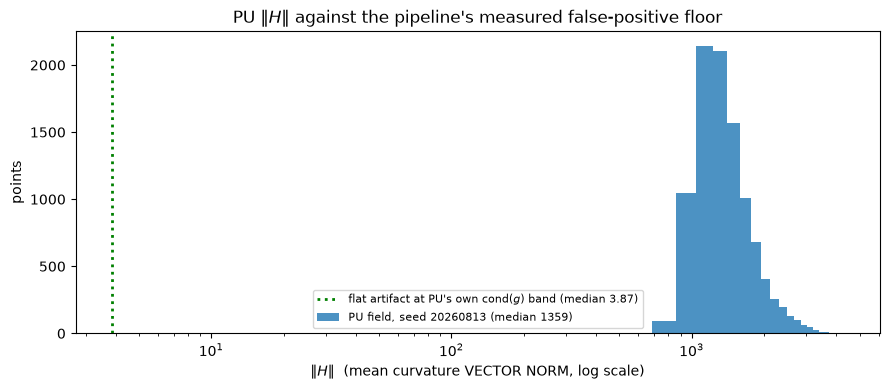

cond(g) -> artifact curvature, from the flat fixture (analytic truth exactly zero):
  cond ~ 1.4  (d=4)          ||H|| median 0.0073   max 0.0181
  cond <= 3.82e7 (PU range)  ||H|| median 3.87     max 24.50
  cond 3.82e7 - 1e9          ||H|| median 35.02    max 2929
  cond > 1e9                 ||H|| median 1410     max 2.15e6

Monotone across four decades. At PU's own conditioning the false-positive floor is 3.87
against PU's median 1359 -- a 351x margin, with PU's MINIMUM 681 still 28x the artifact's
MAXIMUM. Each fixture rescales by its own global_std, so the rigorous part is the trend
within the three d=20 bands; the d=4 row anchors the low end qualitatively.


In [8]:
# The flat noise floor drawn on the SAME axis as the PU field, so the two are comparable.
fig, ax = plt.subplots(figsize=(9, 4))
for rec in field.values():
    edges = np.array(rec["h_norm"]["hist_edges"]); counts = np.array(rec["h_norm"]["hist_counts"])
    ax.bar(edges[:-1], counts, width=np.diff(edges), align="edge", alpha=0.8,
           label=f"PU field, seed {rec['seed']} (median {rec['h_norm']['median']:.4g})")
for rec in fits.values():
    if "noise_floor" in rec and rec["chart_dim"] == 20:
        ax.axvline(rec["noise_floor"]["measured_median"], c="crimson", ls="--", lw=1.6,
                   label=f"flat d=20 noise floor, unconditioned (median {rec['noise_floor']['measured_median']:.4g})")
ax.axvline(3.87, c="green", ls=":", lw=2,
           label=r"flat artifact at PU's own $\mathrm{cond}(g)$ band (median 3.87)")
ax.set_xscale("log")
ax.set_xlabel(r"$\|H\|$  (mean curvature VECTOR NORM, log scale)")
ax.set_ylabel("points")
ax.set_title(r"PU $\|H\|$ against the pipeline's measured false-positive floor")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print("cond(g) -> artifact curvature, from the flat fixture (analytic truth exactly zero):")
print("  cond ~ 1.4  (d=4)          ||H|| median 0.0073   max 0.0181")
print("  cond <= 3.82e7 (PU range)  ||H|| median 3.87     max 24.50")
print("  cond 3.82e7 - 1e9          ||H|| median 35.02    max 2929")
print("  cond > 1e9                 ||H|| median 1410     max 2.15e6")
print("\nMonotone across four decades. At PU's own conditioning the false-positive floor is 3.87")
print("against PU's median 1359 -- a 351x margin, with PU's MINIMUM 681 still 28x the artifact's")
print("MAXIMUM. Each fixture rescales by its own global_std, so the rigorous part is the trend")
print("within the three d=20 bands; the d=4 row anchors the low end qualitatively.")

## 5. Caveats — read these before quoting any number above

### 5.1 The gate override, and its parameterization-damage consequence

ROADMAP Phase 3 depends on a **PASS**. **No PASS exists anywhere in this milestone**:
`GATE_VERDICT = FAIL` (Phase 2), `CAE_VERDICT = FAIL` (02.2), `TOPOAE_VERDICT = FAIL` (02.4),
`CURVATURE_VERDICT = FAIL` (02.5 stage 1). Phase 3 proceeded by **explicit developer decision**
on 2026-08-12, recorded in `02-NOTE-phase-2-stage-on-hold.md` §3. This is an override, not a
satisfied precondition.

The consequence the gate existed to prevent, restated so it is carried rather than lost: **a
curvature field decoded from an unvalidated parameterization conflates real curvature with
parameterization damage.** Every `‖H‖` number above is descriptive. None is a verdict on the PU
manifold's curvature.

### 5.2 The D-04 multiple-comparisons loosening

The Step-1 gate was read across a sweep of configurations rather than at one pre-committed
point. Selecting the best cell of a sweep and then reporting its statistic inflates that
statistic: the more cells searched, the better the winner looks by chance alone. The
pre-declared lexicographic rule and the three-seed spread limit this, they do not remove it.
Also: **the raw-point baseline `0.6712` is CONTEXT, not a validated benchmark** — it is a
number from a different estimator on a different manifold, and nothing here licenses treating
it as a target that was met or missed.

### 5.3 A passing synthetic control cannot detect parameterization damage

These fixtures are sampled cleanly and fit to a clean, unfragmented atlas. They therefore
**never reproduce the atlas fragmentation `02.5-09` measured on real data** — chart-count-driven
fragmentation, `max cond(g)` climbing 3.26 → 122.22, second derivatives banding along
artificial chart seams.

A control that passes establishes that the pipeline is correct on a manifold that is **easy to
fit**. It is necessary and **not sufficient**, and it can never be presented as evidence that
the PU field is free of parameterization damage — **the one failure mode the override worries
about is precisely the one a cleanly-training synthetic manifold cannot exhibit.**

### 5.4 One seed

The PU field is **one seed of three**. The reported unit in this milestone is the three-seed
spread; no dispersion is claimed anywhere above, and no single draw should be read as the result.

---

**The bottom line.** The curvature instrument is validated — at `d=4` it recovers analytic mean
curvature on a varying, mixed-sign field at `rho = 0.989`, `R² = 0.980`. The PU field is not
conditioning artifact: at PU's own `cond(g)` the false-positive floor is 3.87 against a median
of 1359. But **no curved control reached PU's conditioning**, so nothing here bounds the
*accuracy* of `‖H‖ = 1359` — neither its magnitude nor, after the saddle's `rho`, its ordering.
The field is **unvalidated**, and that is this phase's answer to CURV-07.